# 🏠 House Prices: Regression with Neural Networks

The objective of this notebook is to train a neural network model to predict [house prices](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/overview). 

# Preliminaries

In [1]:
# Import packages.
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import category_encoders as ce
from sklearn import metrics, ensemble, model_selection, tree
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, cross_val_predict
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

# Import Deep Learning packages
import tensorflow
from tensorflow import keras
from tensorflow.keras import layers

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
train = pd.read_csv('../input/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('../input/house-prices-advanced-regression-techniques/test.csv')

In [3]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# Data Preprocessing

In [4]:
# Missing Values by features
pct_missing = (train.isnull().sum() / len(train)).sort_values(ascending=False).to_frame(name='mis_pct')
to_drop = pct_missing.query('mis_pct > 0.4').index.to_list()
to_drop

['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu']

In [5]:
# Types of features
# Define feature types.
target = ['SalePrice']
cat_feats = train.drop(columns=['Id', 'SalePrice'] + to_drop).select_dtypes(include='object').columns.tolist()
cont_feats = train.drop(columns=['Id', 'SalePrice'] + to_drop).select_dtypes(include=np.number).columns.tolist()
all_feats = cat_feats + cont_feats
len(train.columns), len(cat_feats), len(cont_feats)

(81, 38, 36)

In [6]:
# Cardinality of categorical features
train.loc[:, cat_feats].nunique().sort_values(ascending=False).head()

Neighborhood    25
Exterior2nd     16
Exterior1st     15
SaleType         9
Condition1       9
dtype: int64

In [7]:
# Define datasets
X = train.loc[:, all_feats]
y = train[target]

X_test = test.loc[:, all_feats]

In [8]:
# Pipeline for categorical feature transformation.
cat_tfms = Pipeline(steps=[
    ('cat_missing_imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(categories='auto', drop=None, sparse=True, handle_unknown='error'))
])

# Pipeline for numeric feature transformation.
cont_tfms = Pipeline(steps=[
    ('cont_imputer', SimpleImputer(strategy='median')),
    ('cont_std_scaler', StandardScaler())
])

# Transform cat & cont features separately and concatenate the features.
ctf = ColumnTransformer(transformers=[
    ('cat_tfms', cat_tfms, cat_feats),
    ('cont_tfms', cont_tfms, cont_feats)
], remainder='passthrough')

In [9]:
X_preproc = ctf.fit_transform(X).todense()

In [10]:
X_preproc.shape

(1460, 270)

In [11]:
X_preproc[:5]

matrix([[ 0.        ,  0.        ,  0.        , ..., -0.08768781,
         -1.5991111 ,  0.13877749],
        [ 0.        ,  0.        ,  0.        , ..., -0.08768781,
         -0.48911005, -0.61443862],
        [ 0.        ,  0.        ,  0.        , ..., -0.08768781,
          0.99089135,  0.13877749],
        [ 0.        ,  0.        ,  0.        , ..., -0.08768781,
         -1.5991111 , -1.36765473],
        [ 0.        ,  0.        ,  0.        , ..., -0.08768781,
          2.10089239,  0.13877749]])

In [12]:
X_test_preproc = ctf.transform(X_test).todense()

In [13]:
X_test_preproc.shape

(1459, 270)

In [14]:
x_train, x_val, y_train, y_val = train_test_split(X_preproc, y, test_size=0.2)

In [15]:
x_train.shape, x_val.shape

((1168, 270), (292, 270))

# Dimensionality Reduction

In [16]:
pca = PCA(n_components=None)
x_train_tf = pca.fit_transform(np.asarray(x_train))
x_test_tf = pca.fit_transform(np.asarray(x_val))

In [17]:
x_train_tf.shape, x_test_tf.shape

((1168, 270), (292, 270))

In [18]:
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >= 0.90) + 1

In [19]:
d

45

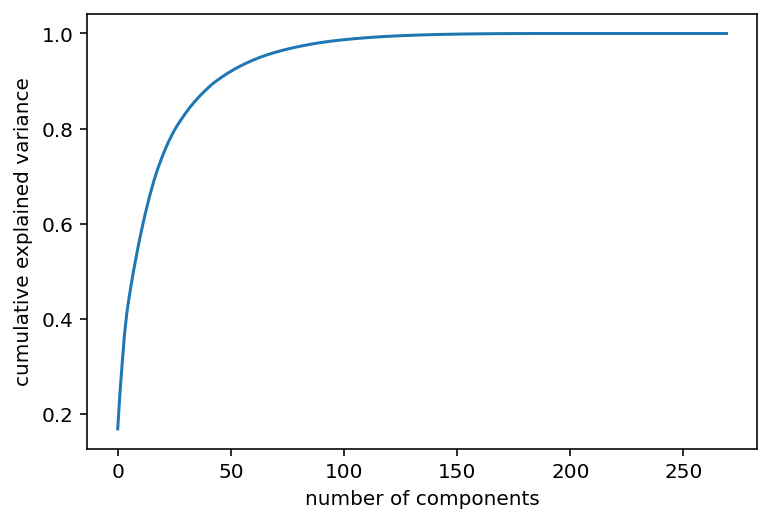

In [20]:
plt.plot(np.cumsum(pca.explained_variance_ratio_));
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance');

In [21]:
pca = PCA(n_components=50)
x_train_reduced = pca.fit_transform(np.asarray(x_train))
x_val_reduced = pca.transform(np.asarray(x_val))
x_test_reduced = pca.transform(np.asarray(X_test_preproc))

In [22]:
x_train_reduced.shape, x_val_reduced.shape, x_test_reduced.shape

((1168, 50), (292, 50), (1459, 50))

# Building a Neural Network

In [23]:
model = keras.Sequential([
  layers.Dense(50, activation='relu', input_dim=50),
  layers.Dense(128, activation='relu', input_dim=128),
  layers.Dense(64, activation='relu', input_dim=64),
  layers.Dense(1, activation='linear')
])

2022-04-22 13:34:16.135515: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-04-22 13:34:16.223576: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-04-22 13:34:16.224321: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-04-22 13:34:16.225465: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compil

In [24]:
model.compile(loss='mse', optimizer='Adam')

In [25]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 50)                2550      
_________________________________________________________________
dense_1 (Dense)              (None, 128)               6528      
_________________________________________________________________
dense_2 (Dense)              (None, 64)                8256      
_________________________________________________________________
dense_3 (Dense)              (None, 1)                 65        
Total params: 17,399
Trainable params: 17,399
Non-trainable params: 0
_________________________________________________________________


In [26]:
history = model.fit(
    x_train_reduced, 
    y_train, 
    epochs=100, 
    validation_data = (x_val_reduced, y_val)
)

2022-04-22 13:34:18.708587: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


Epoch 1/100
37/37 [==============================] - 2s 9ms/step - loss: 39709249536.0000 - val_loss: 36339580928.0000
Epoch 2/100
37/37 [==============================] - 0s 3ms/step - loss: 39675985920.0000 - val_loss: 36265394176.0000
Epoch 3/100
37/37 [==============================] - 0s 3ms/step - loss: 39488475136.0000 - val_loss: 35930775552.0000
Epoch 4/100
37/37 [==============================] - 0s 3ms/step - loss: 38837850112.0000 - val_loss: 34955526144.0000
Epoch 5/100
37/37 [==============================] - 0s 3ms/step - loss: 37159272448.0000 - val_loss: 32763662336.0000
Epoch 6/100
37/37 [==============================] - 0s 3ms/step - loss: 33727088640.0000 - val_loss: 28728965120.0000
Epoch 7/100
37/37 [==============================] - 0s 3ms/step - loss: 28143626240.0000 - val_loss: 22603454464.0000
Epoch 8/100
37/37 [==============================] - 0s 3ms/step - loss: 20610447360.0000 - val_loss: 15059801088.0000
Epoch 9/100
37/37 [=============================

In [27]:
preds_val = model.predict(x_val_reduced)

In [28]:
metrics.r2_score(y_val, preds_val)

0.8981025486775619

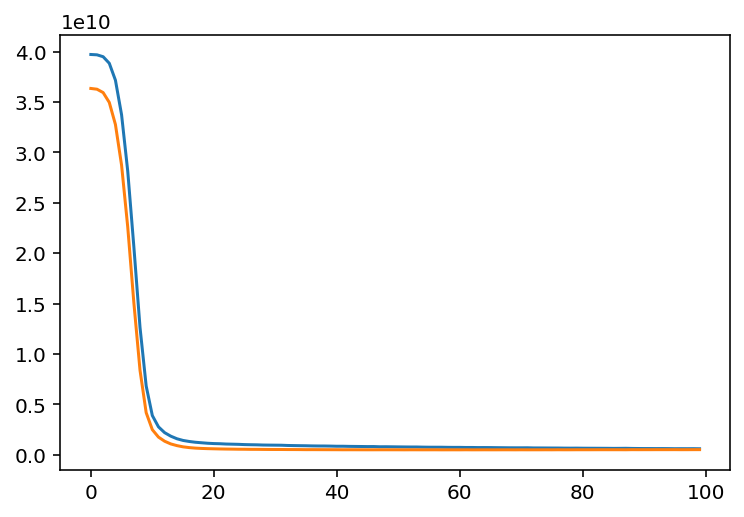

In [29]:
plt.plot(history.history['loss']);
plt.plot(history.history['val_loss']);

In [30]:
preds_test = model.predict(x_test_reduced).ravel()

In [31]:
df_preds = pd.DataFrame({'Id':test.Id , 'SalePrice': preds_test})
df_preds.to_csv('sub3.csv' ,index=False)

# References

* [Wandb Tracking](https://www.loom.com/share/fb64035e4576467489cf0f2ad9cff92a)